In [11]:
import re
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sentence_transformers import SentenceTransformer
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping

# ================================================
# STAP 1 - BERT preprocessing (minimaal!)
# Geen stopwords, geen lemmatization!
# BERT begrijpt context zelf
# ================================================
def preprocess_bert(text):
    text = text.lower()
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# Toepassen op ORIGINELE data uit df
# NIET op X_train die al gecleaned is!

X_train_bert = X_train.apply(preprocess_bert)  # ← X_train niet X_train_full!
X_val_bert   = X_val.apply(preprocess_bert)
X_test_bert  = X_test.apply(preprocess_bert)

print('BERT preprocessing klaar!')
print('Voorbeeld:', X_train_bert.values[0])

# ================================================
# STAP 2 - BERT Embeddings berekenen
# Zet elke zin om naar vector van 384 getallen
# ================================================
model_st = SentenceTransformer('all-MiniLM-L6-v2', device='mps')

print('Embeddings berekenen...')
X_train_emb = model_st.encode(X_train_bert.tolist(), show_progress_bar=True)
X_val_emb   = model_st.encode(X_val_bert.tolist(),   show_progress_bar=True)
X_test_emb  = model_st.encode(X_test_bert.tolist(),  show_progress_bar=True)

print('Shape embeddings:', X_train_emb.shape)  # (21856, 384)

# ================================================
# STAP 3 - Neural Network trainen op embeddings
# ================================================
model_nn_bert = Sequential([
    Dense(256, activation='relu', input_shape=(X_train_emb.shape[1],)),
    BatchNormalization(),
    Dropout(0.3),
    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])

model_nn_bert.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model_nn_bert.summary()

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

history = model_nn_bert.fit(
    X_train_emb, y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_val_emb, y_val),
    callbacks=[early_stop]
)

# ================================================
# STAP 4 - Evaluatie
# ================================================
y_train_pred = (model_nn_bert.predict(X_train_emb) > 0.5).astype(int)
y_val_pred   = (model_nn_bert.predict(X_val_emb)   > 0.5).astype(int)
y_test_pred  = (model_nn_bert.predict(X_test_emb)  > 0.5).astype(int)

train_acc = accuracy_score(y_train, y_train_pred)
val_acc   = accuracy_score(y_val,   y_val_pred)
test_acc  = accuracy_score(y_test,  y_test_pred)
train_f1  = f1_score(y_train,       y_train_pred)
val_f1    = f1_score(y_val,         y_val_pred)
test_f1   = f1_score(y_test,        y_test_pred)

print(f'\nNN + BERT embeddings:')
print(f'Train → Acc: {train_acc:.3f} | F1: {train_f1:.3f}')
print(f'Val   → Acc: {val_acc:.3f}   | F1: {val_f1:.3f}')
print(f'Test  → Acc: {test_acc:.3f}  | F1: {test_f1:.3f}')

BERT preprocessing klaar!
Voorbeeld: merkel admits mistakes in the 2016 christmas market attack


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 6276.98it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Embeddings berekenen...


Batches: 100%|██████████| 214/214 [00:03<00:00, 63.10it/s]

Shape embeddings: (21856, 384)


...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_20 (Dense)                │ (None, 256)            │        98,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 141,313 (552.00 KB)

 Trainable params: 140,545 (549.00 KB)

 Non-trainable params: 768 (3.00 KB)

Epoch 1/20
683/683 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8838 - loss: 0.2737 - val_accuracy: 0.9274 - val_loss: 0.1739
Epoch 2/20
683/683 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9200 - loss: 0.1978 - val_accuracy: 0.9290 - val_loss: 0.1654
Epoch 3/20
683/683 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9312 - loss: 0.1678 - val_accuracy: 0.9400 - val_loss: 0.1507
Epoch 4/20
683/683 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9424 - loss: 0.1475 - val_accuracy: 0.9392 - val_loss: 0.1547
Epoch 5/20
683/683 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9471 - loss: 0.1348 - val_accuracy: 0.9425 - val_loss: 0.1458
Epoch 6/20
683/683 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9537 - loss: 0.1203 - val_accuracy: 0.9433 - val_loss: 0.1431
Epoch 7/20
683/683 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9552 - loss: 0.1110 - val_accuracy: 0.9429 - val_loss: 0.1545
Epoch 8/20
683/683 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9618 - loss: 0.0969 - val_accuracy: 0.

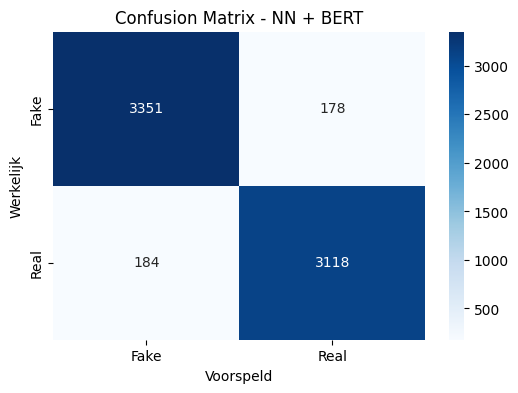

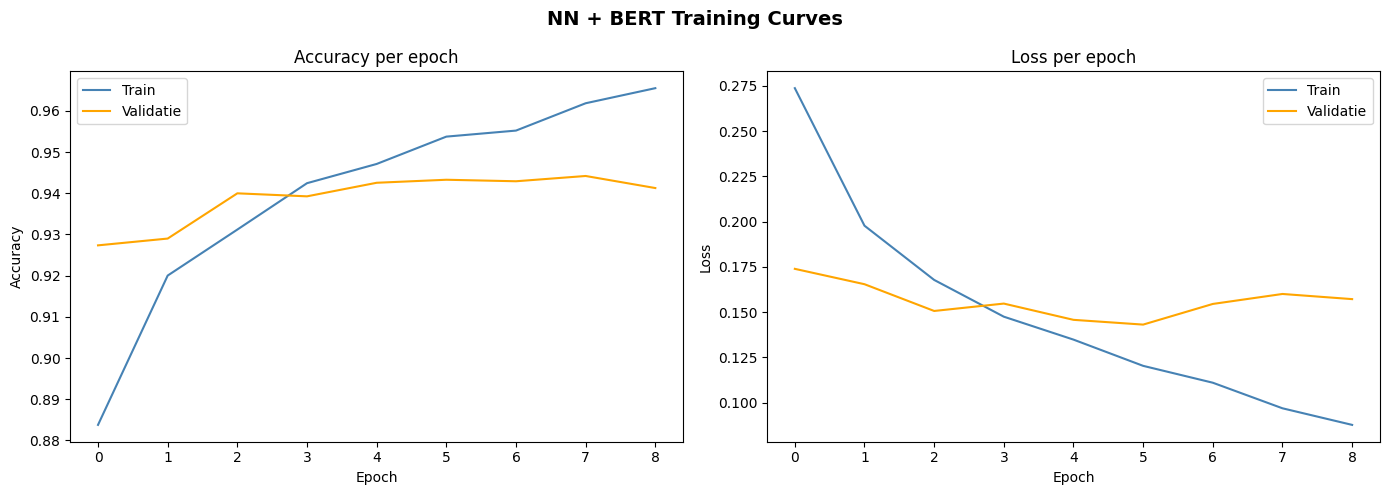

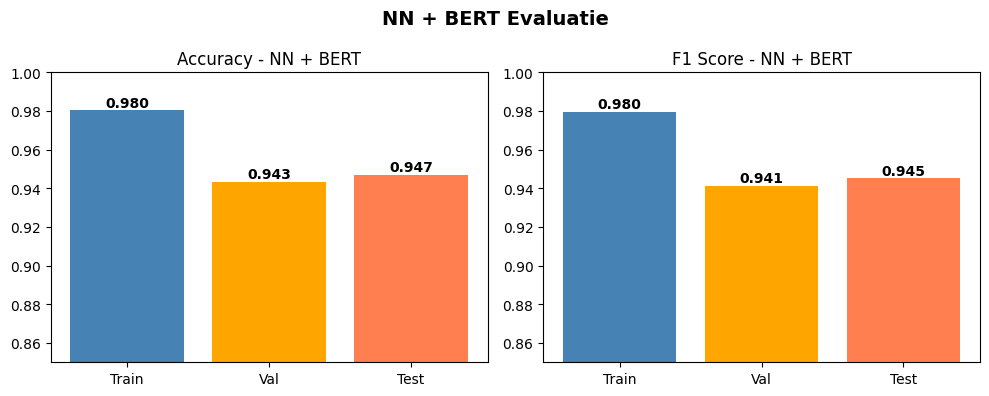

In [12]:
# Confusion Matrix NN + BERT
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_test_pred), annot=True, fmt='d', cmap='Blues',
            xticklabels=['Fake', 'Real'], yticklabels=['Fake', 'Real'])
plt.title('Confusion Matrix - NN + BERT')
plt.xlabel('Voorspeld')
plt.ylabel('Werkelijk')
plt.show()

# Train vs Val accuracy en loss curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
axes[0].plot(history.history['accuracy'],     label='Train', color='steelblue')
axes[0].plot(history.history['val_accuracy'], label='Validatie', color='orange')
axes[0].set_title('Accuracy per epoch')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

# Loss
axes[1].plot(history.history['loss'],     label='Train', color='steelblue')
axes[1].plot(history.history['val_loss'], label='Validatie', color='orange')
axes[1].set_title('Loss per epoch')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.suptitle('NN + BERT Training Curves', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Train vs Test bar plot
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].bar(['Train', 'Val', 'Test'], [train_acc, val_acc, test_acc], color=['steelblue', 'orange', 'coral'])
axes[0].set_title('Accuracy - NN + BERT')
axes[0].set_ylim(0.85, 1.0)
for i, v in enumerate([train_acc, val_acc, test_acc]):
    axes[0].text(i, v + 0.002, f'{v:.3f}', ha='center', fontweight='bold')

axes[1].bar(['Train', 'Val', 'Test'], [train_f1, val_f1, test_f1], color=['steelblue', 'orange', 'coral'])
axes[1].set_title('F1 Score - NN + BERT')
axes[1].set_ylim(0.85, 1.0)
for i, v in enumerate([train_f1, val_f1, test_f1]):
    axes[1].text(i, v + 0.002, f'{v:.3f}', ha='center', fontweight='bold')

plt.suptitle('NN + BERT Evaluatie', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()